<a href="https://colab.research.google.com/github/expely/Business-Analytics-Labs/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [28]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


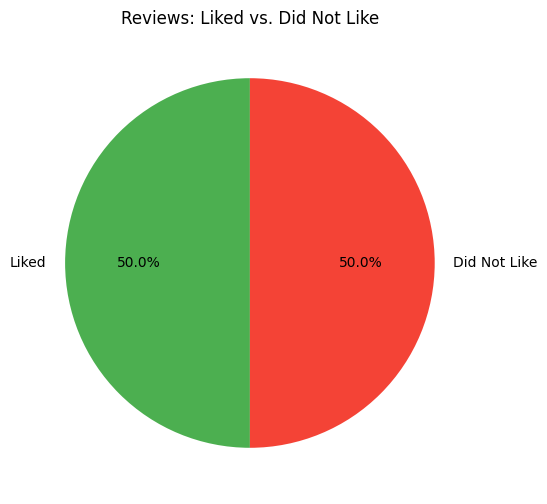

In [29]:
import matplotlib.pyplot as plt

# Overall Liked percentage
counts_liked = df['Liked'].value_counts()

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts_liked,
    labels=['Liked', 'Did Not Like'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#F44336']
)
plt.title('Reviews: Liked vs. Did Not Like')
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [30]:
# Change reviews to lowercase letters
df_cleaned = df
df_cleaned['Review'] = df_cleaned['Review'].str.lower()

# Remove any URL
df_cleaned['Review'] = df_cleaned['Review'].str.replace(r'http\S+|www\.\S+', '', regex=True)

# Only keep A-Z and Numbers, removing punctuation
df_cleaned['Review'] = df_cleaned['Review'].str.replace(r'[^A-Za-z0-9\s]', '', regex=True)

### ✍️ Your Response: 🔧
1. One of the common issues would be overfitting. If we include a lot of this data, the model will create false relationships, because it breaks down each item as a word or into tokens, we might have a case where 'https' occurs a few times and will be heavily weighted to one side. Another one would be seeing items like 'crust!' and 'crust' as different words, which to a human they're the same.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [31]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [32]:
from nltk.sentiment import SentimentIntensityAnalyzer

# set up and run the VADER model
sia = SentimentIntensityAnalyzer()

df_cleaned["vader_score"] = [sia.polarity_scores(text)["compound"] for text in df_cleaned["Review"]]

# Map score to positive, negative, and neutral
def score_to_label(score):
    if score >= 0.05:
      return 'Positive'
    elif score <= -0.05:
      return 'Negative'
    else:
      return 'Neutral'

df_cleaned["vader_pred"] = df_cleaned["vader_score"].apply(score_to_label)

# View the predicted score
print(df_cleaned.head())

# Calculate percentage of reviews
print(df_cleaned['vader_pred'].value_counts(normalize=True) * 100)

                                              Review  Liked  vader_score  \
0                               wow loved this place      1       0.8271   
1                                  crust is not good      0      -0.3412   
2           not tasty and the texture was just nasty      0      -0.5574   
3  stopped by during the late may bank holiday of...      1       0.6908   
4  the selection on the menu was great and so wer...      1       0.6249   

  vader_pred  
0   Positive  
1   Negative  
2   Negative  
3   Positive  
4   Positive  
vader_pred
Positive    50.3
Negative    25.5
Neutral     24.2
Name: proportion, dtype: float64


### ✍️ Your Response: 🔧
1. It shows a lot more broad picture. Instead of just being a simple 50/50 positive to negative reviews, the vader prediction shows 50% positive, 25/25 negative and neutral reviews.

2. Negative and neutral are going to be more important to analyze, as you can expect to keep the positive happy, while improving upon what the negative and neutral dislike. It's definitely worth checking the positive reviews after coming up with a plan to make sure it doesn't conflict with their sentiment.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [33]:
# Download NLTK Corpora
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [34]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Create stop_words and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocess Function
def preprocess_text(text):
    # Tokenization (split the string into individual words)
    tokens = word_tokenize(text)

    # Remove stopwords and Lemmatize
    processed_tokens = []
    for word in tokens:
        if word not in stop_words:
            # Lemmatize converts words to their base form (e.g., "pizzas" -> "pizza", "loving" -> "love")
            base_word = lemmatizer.lemmatize(word)
            processed_tokens.append(base_word)

    # Step D: Rejoin the processed tokens back into a single string
    return ' '.join(processed_tokens)

# Process Text
df_cleaned['Processed_Review'] = df_cleaned['Review'].apply(preprocess_text)

df_cleaned.head(10)

,Review,Liked,vader_score,vader_pred,Processed_Review
0,wow loved this place,1,0.8271,Positive,wow loved place
1,crust is not good,0,-0.3412,Negative,crust good
2,not tasty and the texture was just nasty,0,-0.5574,Negative,tasty texture nasty
3,stopped by during the late may bank holiday of...,1,0.6908,Positive,stopped late may bank holiday rick steve recom...
4,the selection on the menu was great and so wer...,1,0.6249,Positive,selection menu great price
5,now i am getting angry and i want my damn pho,0,-0.6908,Negative,getting angry want damn pho
6,honeslty it didnt taste that fresh,0,-0.2411,Negative,honeslty didnt taste fresh
7,the potatoes were like rubber and you could te...,0,0.5719,Positive,potato like rubber could tell made ahead time ...
8,the fries were great too,1,0.6249,Positive,fry great
9,a great touch,1,0.6249,Positive,great touch


### ✍️ Your Response: 🔧
1. Text analysis isn't as simple as splitting into training and testing for the same dataset. We have grammar, rules, societal clauses, etc. that exist outside of the dataset. The corpora is that collection of "training" data that we use to train a model against a dataset.

2. The tokens would simplify down to `wow` `...` `loved` `this` `place`. But, `this` is a stop word, and `...` is not regular text, so we'd get rid of them.

3. Lemmatization converts words into their base form so they're all weighed the same. Like `laughed` would become `laugh`. It avoids the earlier concept I talked about where the model might create false relationships between `laughed` and weigh it more than `laugh` even though they should be treated the same.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [35]:
!pip install gensim

In [36]:
from gensim import corpora

# Split reviews into a list of tokens
tokenized_reviews = [review.split() for review in df_cleaned['Processed_Review']]

# Create Dictionary from the reviews
dictionary = corpora.Dictionary(tokenized_reviews)

# Create the Corpus (Bag of Words)
corpus = [dictionary.doc2bow(review) for review in tokenized_reviews]

# Display Summary
print("--- Dictionary Summary ---")
print(dictionary)

print("\n--- Corpus Summary ---")
print(f"Total documents in corpus: {len(corpus)}")
print("\n--- First 2 Corpus Entries ---")
for i in range(2):
    print(f"Review {i+1} Original words: {tokenized_reviews[i]}")
    print(f"Review {i+1} Bag of Words : {corpus[i]}\n")

--- Dictionary Summary ---
Dictionary<1839 unique tokens: ['loved', 'place', 'wow', 'crust', 'good']...>

--- Corpus Summary ---
Total documents in corpus: 1000

--- First 2 Corpus Entries ---
Review 1 Original words: ['wow', 'loved', 'place']
Review 1 Bag of Words : [(0, 1), (1, 1), (2, 1)]

Review 2 Original words: ['crust', 'good']
Review 2 Bag of Words : [(3, 1), (4, 1)]



### ✍️ Your Response: 🔧
1. A corpus is the actual sentences, paragraphs, works of the entire document. It's useful to let the computer figure out the statistical model of the raw text. The model will find the conenctions between words in the total works of our reviews.

2. A dictionary is the vocabular, instead of the raw reviews, it just takes all the tokens as that. Translating the tokens into identifiers for better statistical modeling. Like `wow` lives at `(0, 1)` which a computer can interpret a lot better than just `wow`.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [37]:
from gensim.models import LdaModel

number_of_topics = 5

# Create and train the model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=number_of_topics,
    random_state=42,
    passes=10
)

# Display the Discovered topics
print("--- Discovered Topics ---")
# This prints the topics and the words that make them up
topics = lda_model.print_topics(num_words=3) # Showing the top 3 words per topic

for topic in topics:
    print(f"Topic {topic[0]}: {topic[1]}")

--- Discovered Topics ---
Topic 0: 0.025*"good" + 0.019*"place" + 0.019*"food"
Topic 1: 0.017*"good" + 0.015*"place" + 0.013*"also"
Topic 2: 0.015*"place" + 0.013*"great" + 0.011*"minute"
Topic 3: 0.033*"food" + 0.023*"back" + 0.013*"like"
Topic 4: 0.038*"service" + 0.023*"place" + 0.022*"great"


### ✍️ Your Response: 🔧
1. Any case where there are a lot more relationships then just 5 topics! Like Amazon and Google Reviews are going to have a lot more than just 5 topics that the reviews talk about. The reviews topics are going to highly differ from product to product.

2. We can check ourselves to see if a lot of the same words exist in multiple topics. Like Topic 0 and 1 have both "good" and "place" as their top 2 words. It's worth looking into those and making sure they're rather unique topics.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


In [38]:
from wordcloud import WordCloud
import warnings

# Suppress unhelpful Python warnings to keep the output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Display the Discovered topics
print("--- Discovered Topics ---")
# This prints the topics and the words that make them up
topics = lda_model.print_topics(num_words=10) # Showing the top 10 words per topic

for topic in topics:
    print(f"Topic {topic[0]}: {topic[1]}")

# Assign topics to the reviews
dominant_topics = []

for review_bow in corpus:
    # Get the topic probabilities for this specific review
    topic_probs = lda_model.get_document_topics(review_bow)
    # Sort them by probability to find the highest one
    dominant_topic = sorted(topic_probs, key=lambda x: x[1], reverse=True)[0][0]
    dominant_topics.append(dominant_topic)

# Add it back to the DataFrame
df_cleaned['Dominant_Topic'] = dominant_topics

print("\n--- Topic Frequency ---")
# Count how many reviews were assigned to each topic
topic_counts = df_cleaned['Dominant_Topic'].value_counts().sort_index()
for topic_id, count in topic_counts.items():
    print(f"Topic {topic_id}: {count} reviews")

--- Discovered Topics ---
Topic 0: 0.025*"good" + 0.019*"place" + 0.019*"food" + 0.015*"dont" + 0.010*"time" + 0.010*"go" + 0.009*"best" + 0.009*"would" + 0.008*"star" + 0.007*"back"
Topic 1: 0.017*"good" + 0.015*"place" + 0.013*"also" + 0.012*"friendly" + 0.012*"time" + 0.009*"ive" + 0.007*"go" + 0.007*"back" + 0.007*"waited" + 0.006*"loved"
Topic 2: 0.015*"place" + 0.013*"great" + 0.011*"minute" + 0.011*"food" + 0.010*"amazing" + 0.009*"like" + 0.007*"taste" + 0.007*"pretty" + 0.006*"ordered" + 0.006*"flavor"
Topic 3: 0.033*"food" + 0.023*"back" + 0.013*"like" + 0.013*"ever" + 0.011*"wont" + 0.011*"service" + 0.008*"one" + 0.008*"best" + 0.007*"even" + 0.007*"go"
Topic 4: 0.038*"service" + 0.023*"place" + 0.022*"great" + 0.015*"food" + 0.014*"good" + 0.009*"restaurant" + 0.008*"time" + 0.008*"delicious" + 0.007*"well" + 0.007*"definitely"

--- Topic Frequency ---
Topic 0: 205 reviews
Topic 1: 164 reviews
Topic 2: 178 reviews
Topic 3: 209 reviews
Topic 4: 244 reviews


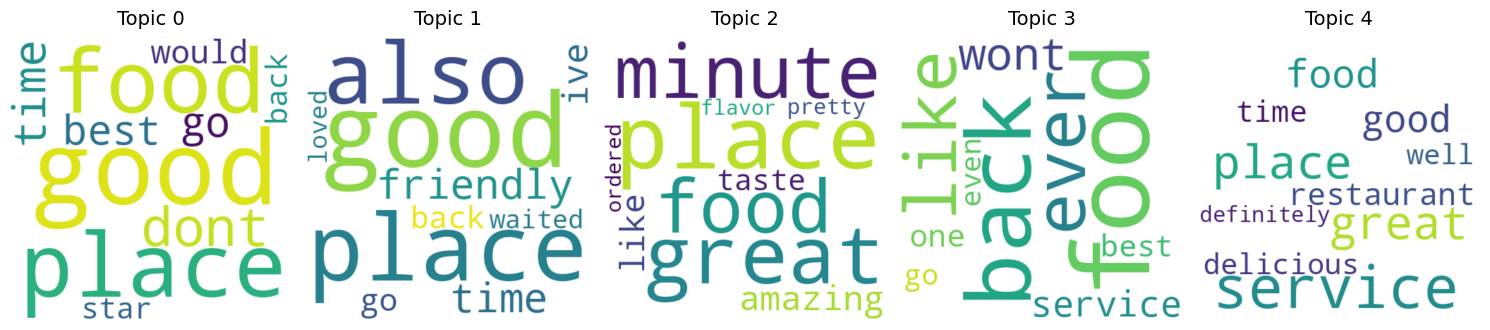

In [39]:
# Create the word cloud
fig, axes = plt.subplots(1, lda_model.num_topics, figsize=(15, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    # WordCloud needs a dictionary of {word: probability}
    topic_words_dict = dict(lda_model.show_topic(i, topn=10))

    # Generate the cloud
    cloud = WordCloud(
        background_color='white',
        width=400,
        height=400,
        colormap='viridis'
    ).generate_from_frequencies(topic_words_dict)

    # Display it cleanly on the axes
    ax.imshow(cloud, interpolation='bilinear')
    ax.set_title(f"Topic {i}", fontsize=14, pad=10)
    ax.axis('off') # Turns off the X/Y axes lines and numbers

plt.tight_layout()
plt.show()

In [40]:
# Summarize Sentiment by Topic
print("\n--- Sentiment Percentage by Topic ---")

# pd.crosstab compares two columns.
# normalize='index' turns raw counts into row percentages.
sentiment_summary = pd.crosstab(
    df_cleaned['Dominant_Topic'],
    df_cleaned['vader_pred'],
    normalize='index'
) * 100

# Format the output to 1 decimal place and add a % sign
sentiment_summary_formatted = sentiment_summary.round(1).astype(str) + '%'

# Rename the index so it looks nicer when printed
sentiment_summary_formatted.index = [f"Topic {i}" for i in sentiment_summary_formatted.index]
print(sentiment_summary_formatted)


--- Sentiment Percentage by Topic ---
vader_pred Negative Neutral Positive
Topic 0       22.4%   29.3%    48.3%
Topic 1       25.6%   25.0%    49.4%
Topic 2       27.5%   22.5%    50.0%
Topic 3       28.2%   28.7%    43.1%
Topic 4       24.2%   16.8%    59.0%


### ✍️ Your Response: 🔧
List your topics and names here:
- Topic 0: Overall Food & Place
- Topic 1: Wait Times
- Topic 2: Speedy for Foodies
- Topic 3: Polarizing Experiences
- Topic 4: Top-Tier Customers

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. The business questions would be: How can we more accurately understand customer reviews?

2. I would recommend really diving into the polarizing experiences and reading through the Topic 3 review to see why a lot more people disliked the services than the rest. This topic has the highest gap between neutral and negative to their positive reviews. Another recommendation is to look at what Topic 4 is doing right to convert more neutral customers to positive ones, and apply that same strategy across the board.

3. The pros would be that we as humans would have a much easier time understanding the output. An LLM would be able to look at all the text, and spit out a very readable and informing summary of everything. But, having Python code makes it far more based in facts and statistics. An LLM can hallucinate, and is designed to be non-deterministic (with some caveats). Python guarantess that our data is based in fact and is highly reproducable.

4. You are a restaurant owner who wants to better understand their customer reviews so that you can improve customer satisfaction. Given the following `reviews`, when analyzing their `sentiment`, then split up the data into 5 topics with improvements on each one.

reviews:
"""
review data here...
"""

sentiment:
```
sentiment_types:
  [positive,
  negative,
  neutral]
```

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [41]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] Converting notebook assignment_13_text_analytics.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 677900 bytes to assignment_13_text_analytics.html
